# 04 - Survey analytics: from ground positions to numbers a survey reports

The previous notebooks put animals on the ground and linked them into tracks. A wildlife survey wants more than dots on a map: how far from the flight line were they seen (and so, how many were missed), how dense are they, how much ground did the flight actually look at, and - per transect - how many animals per hectare, with an honest uncertainty. `bambi.survey` does all of that on arrays; this notebook runs it end to end on flight 146.

Every function here mirrors a step of the QGIS plugin's *Survey Analytics* group and agrees with it to floating point (see `tests/test_survey_*.py`); the population estimators additionally reproduce the R/glmmTMB analysis of Praschl et al. 2026 they were ported from.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("."))
from _setup import ensure_environment, get_flight, get_dem, find
ensure_environment()

import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon


bambi-detection ready. data dir: C:\D\Projects\bambi_detection\.test-data


## Setup: the tracked animals of flight 146, on the ground

Exactly the recipe of `02_georeference` and `03_tracking`: DEM, DEM-local poses, the annotated boxes on the ground, linked into tracks. Positions stay DEM-local metres for the maths; the DEM origin is added back only when a file for a GIS is written.

In [2]:
from bambi.io.dem import read_dem_mesh
from bambi.io.poses import read_poses, to_local_poses
from bambi.io.corrections import read_corrections, corrections_for_frames
from bambi.io.tracks import read_mot
from bambi.geo.georef import boxes_to_world_by_frame, corners_to_extent, footprint
from bambi.geo.camera import cameras_from_poses
from bambi.tracking.iou import track_boxes

flight = get_flight("146", version="base")
dem = read_dem_mesh(get_dem("146"))
pf = read_poses(find(flight, "*_matched_poses.json")[0])
poses = to_local_poses(pf, epsg=dem.origin.epsg, origin=dem.origin)
t_corr, r_corr = corrections_for_frames(read_corrections(flight / "146_correction.json"), len(poses))
EPSG = dem.origin.epsg
ORIGIN = np.array([dem.origin.easting, dem.origin.northing])        # DEM-local -> world CRS

W = H = 1024
FOVY = 50.0
gt = read_mot(flight / "146_gt.txt")
ground = corners_to_extent(boxes_to_world_by_frame(gt.frames, gt.boxes, poses, FOVY, W, H, dem.mesh, t_corr, r_corr))
centres = np.column_stack([0.5 * (ground[:, 0] + ground[:, 3]), 0.5 * (ground[:, 1] + ground[:, 4]), 0.5 * (ground[:, 2] + ground[:, 5])])
track_ids = track_boxes(gt.frames, ground, mode="hungarian", iou_threshold=0.3)
n_tracks = len(np.unique(track_ids))
print(f"{len(gt)} detections on frames {gt.frames.min()}..{gt.frames.max()} -> {n_tracks} tracks")

flight 146 (base) cached at C:\D\Projects\bambi_detection\.test-data\base\146
flight 146 (base) cached at C:\D\Projects\bambi_detection\.test-data\base\146


243 detections on frames 1889..3631 -> 16 tracks


## 1 - The flight route and perpendicular distances

Line-transect distance sampling is built on one number per animal: its perpendicular distance to the line the observer travelled. The route is the camera's ground path (`Poses.positions`); `bambi.survey.transects.cumulative_distances` gives the metres flown up to each frame - the effort. `perpendicular_to_route` then drops each detection onto the route the way the plugin does: it takes the route segment the *drone was on* at that frame (nearest to the camera position) and projects perpendicularly onto that segment's line, so a detection is never snapped to a neighbouring, parallel pass.

whole flight 1532 m; the annotated stretch (frames 1889-3631) is 227 m


perpendicular distances: min 4.5 m, median 11.7 m, max 17.3 m


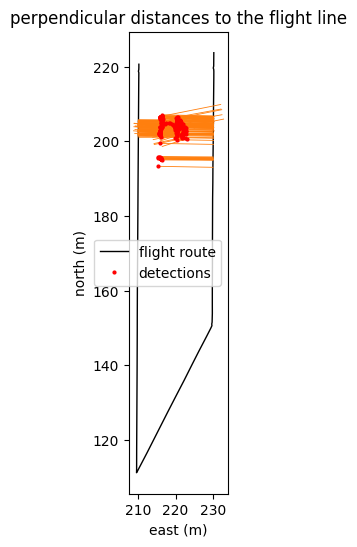

In [3]:
from bambi.survey.transects import cumulative_distances, path_length, centerline
from bambi.survey.perpendicular import perpendicular_to_route, route_length

route = poses.positions[:, :2]
cum = cumulative_distances(route)
first, last = int(gt.frames.min()), int(gt.frames.max())
L = path_length(cum, first, last)                                       # effort: metres flown while the animals were in view
print(f"whole flight {cum[-1]:.0f} m; the annotated stretch (frames {first}-{last}) is {L:.0f} m")

cam_xy = poses.positions[gt.frames, :2]
foot, dist = perpendicular_to_route(centres[:, :2], route, camera_positions=cam_xy)
print(f"perpendicular distances: min {dist.min():.1f} m, median {np.median(dist):.1f} m, max {dist.max():.1f} m")

fig, ax = plt.subplots(figsize=(7, 6))
seg = centerline(poses.positions, first, last)
ax.plot(seg[:, 0], seg[:, 1], "k-", lw=1, label="flight route")
for (x, y), (fx, fy) in zip(centres[:, :2], foot):
    ax.plot([x, fx], [y, fy], "-", color="tab:orange", lw=0.6)
ax.plot(centres[:, 0], centres[:, 1], "r.", ms=4, label="detections")
ax.set_aspect("equal"); ax.legend(); ax.set_xlabel("east (m)"); ax.set_ylabel("north (m)")
ax.set_title("perpendicular distances to the flight line"); plt.show()

The plugin stores these as `flight_route_t/perpendicular_t.json`; `bambi.io.survey` writes the same file (in the world CRS):

In [4]:
from bambi.io.survey import write_perpendicular_json, write_route_geojson

out_dir = flight / "survey_demo"; out_dir.mkdir(exist_ok=True)
write_route_geojson(out_dir / "flight_route.geojson", np.column_stack([route + ORIGIN, poses.positions[:, 2]]), EPSG)
p = write_perpendicular_json(out_dir / "perpendicular_t.json", gt.frames, centres + [*ORIGIN, 0], foot + ORIGIN, dist,
                             gt.confidences, gt.classes, EPSG)
print(p.name, "->", json.loads(p.read_text())["perpendiculas"][0])

perpendicular_t.json -> {'det_idx': 0, 'frame': 1889, 'confidence': 1.0, 'class_id': 61, 'detection_center': [466298.93229152693, 5165791.315905545, 37.966849765541966], 'foot_point': [466312.64376708504, 5165791.303283344], 'distance_m': 13.7115}


## 2 - Distance sampling: how many were missed?

Animals far from the line are seen less often. `estimate_density` fits that fall-off - a half-normal and a hazard-rate detection function by maximum likelihood, best AIC wins - and turns it into an *effective strip width*, an average detection probability, a density and an abundance for the strip that was covered, each with a lognormal 95 % CI. The distances are truncated at the 95th percentile unless you say otherwise.

Boar in a wooded enclosure at 30-40 m altitude are not the textbook case: the thermal frame is only about 30 m wide on the ground, every animal in it is seen, and there is no fall-off with distance for the model to describe. Expect a *flat* detection function (a huge half-normal sigma, detection probability 1) - the machinery working correctly on data that has nothing to tell it. On a wide RGB frame, or with animals visible beyond the frame edge in a light-field integral, the curve does what the textbook says.

n = 230 (of 243) within w = 14.4 m; best model half-normal, 7.85e+09
effective strip half-width 14.4 m -> detection probability 1.00
density 35152 per km2 (95% CI 30894-39995), abundance in the covered strip 230.0 (CI 202.1-261.7)
   half-normal  AIC  1229.36  ESW  14.41 m  CV(ESW) 0.000
   hazard-rate  AIC  1231.36  ESW  14.41 m  CV(ESW) 0.000


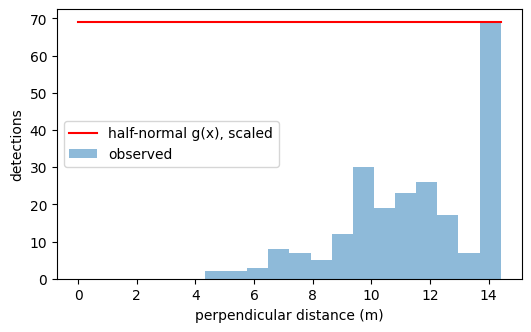

In [5]:
from bambi.survey.distance_sampling import estimate_density

r = estimate_density(dist, transect_length=L)
print(f"n = {r.n} (of {r.n_before_truncation}) within w = {r.truncation_m:.1f} m; best model {r.best.name}, "
      + ", ".join(f"{v:.3g}" for v in r.best.params))
print(f"effective strip half-width {r.effective_strip_width_m:.1f} m -> detection probability {r.detection_probability:.2f}")
print(f"density {r.density_per_km2:.0f} per km2 (95% CI {r.density_ci95[0]:.0f}-{r.density_ci95[1]:.0f}), "
      f"abundance in the covered strip {r.abundance_in_covered_area:.1f} (CI {r.abundance_ci95[0]:.1f}-{r.abundance_ci95[1]:.1f})")
for m in r.models:
    print(f"   {m.name:12s} AIC {m.aic:8.2f}  ESW {m.esw:6.2f} m  CV(ESW) {m.cv_esw:.3f}")

fig, ax = plt.subplots(figsize=(6, 3.5))
widths = np.diff(r.histogram_edges)
scale = r.histogram_counts.max() / max(r.curve_g.max(), 1e-9)
ax.bar(r.histogram_edges[:-1], r.histogram_counts, width=widths, align="edge", alpha=0.5, label="observed")
ax.plot(r.curve_x, r.curve_g * scale, "r-", label=f"{r.best.name} g(x), scaled")
ax.set_xlabel("perpendicular distance (m)"); ax.set_ylabel("detections"); ax.legend(); plt.show()

Note the difference to `01`-`03`: those notebooks are about *positions*, this one about *inference*. The 243 detections are the same 16 animals seen again and again, so a per-detection density double counts; the plugin lets you run the same step on tracks (one distance per track, from its last position). Same call, different input:

In [6]:
last_row = np.array([np.flatnonzero(track_ids == t)[np.argmax(gt.frames[track_ids == t])] for t in np.unique(track_ids)])
foot_t, dist_t = perpendicular_to_route(centres[last_row, :2], route, camera_positions=cam_xy[last_row])
r_t = estimate_density(dist_t, transect_length=L)
print(f"tracks: n = {r_t.n}, ESW {r_t.effective_strip_width_m:.1f} m, density {r_t.density_per_km2:.0f} per km2, abundance in strip {r_t.abundance_in_covered_area:.1f}")

tracks: n = 15, ESW 14.7 m, density 2253 per km2, abundance in strip 15.0


## 3 - Where are they? A density surface

`kde_grid` bins the positions on a raster, smooths them with a Gaussian of `bandwidth` metres and scales the result to **animals per hectare**; cells with no signal are `NODATA` so a GIS renders them transparent. `bambi.io.raster.write_single_band` writes it as a GeoTIFF - the plugin's `analytics_t/density_tracks.tif`, cell for cell.

grid (31, 28), cell 2.0 m; peak 352.67 animals/ha


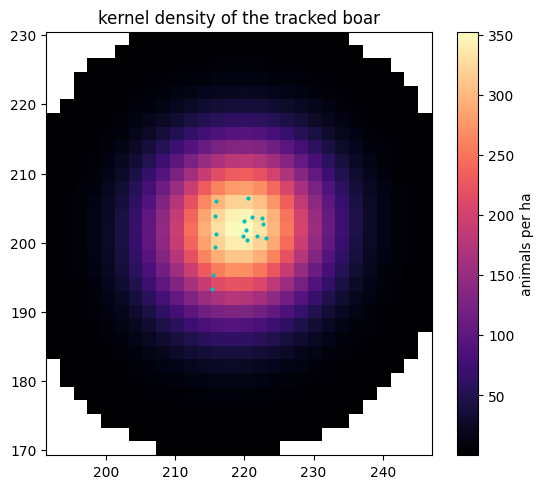

In [7]:
from bambi.survey.density import kde_grid, NODATA
from bambi.io.raster import write_single_band

track_pts = centres[last_row, :2]
g = kde_grid(track_pts, cell_size=2.0, bandwidth=8.0)
valid = g.values[g.values != NODATA]
print(f"grid {g.values.shape}, cell {g.cell_size} m; peak {valid.max():.2f} animals/ha")
world_bounds = (g.bounds[0] + ORIGIN[0], g.bounds[1] + ORIGIN[1], g.bounds[2] + ORIGIN[0], g.bounds[3] + ORIGIN[1])
write_single_band(out_dir / "density_tracks.tif", g.values, world_bounds, EPSG, nodata=NODATA, description="density_points_per_hectare")

fig, ax = plt.subplots(figsize=(6.5, 5.5))
shown = np.where(g.values == NODATA, np.nan, g.values)
im = ax.imshow(shown, extent=(g.bounds[0], g.bounds[2], g.bounds[1], g.bounds[3]), origin="upper", cmap="magma")
ax.plot(track_pts[:, 0], track_pts[:, 1], "c.", ms=4); ax.set_aspect("equal")
plt.colorbar(im, label="animals per ha"); ax.set_title("kernel density of the tracked boar"); plt.show()

## 4 - What ground was actually looked at?

The denominator of every density is *monitored* area, not study area. `bambi.geo.georef.footprint` gives the ground polygon each frame saw; `coverage_grid` counts, per cell, how many frames covered it. (The plugin derives the same map from the exported GeoTIFFs; footprints do it without the renders.)

349 footprints (every 5th frame): 0.99 ha seen at least once, 0.97 ha by five or more frames; max overlap 152


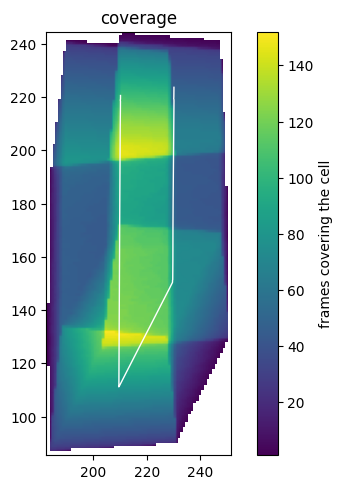

In [8]:
from bambi.survey.density import coverage_grid

step = 5
frames_fp = np.arange(first, last + 1, step)
cams = cameras_from_poses(poses, FOVY, W / H, t_corr, r_corr, indices=frames_fp)
footprints = [footprint(cam, W, H, dem.mesh) for cam in cams]              # (4, 3) each, NaN for misses
cov = coverage_grid(footprints, cell_size=1.0)
seen = cov.values > 0
print(f"{len(footprints)} footprints (every {step}th frame): {seen.sum() / 1e4:.2f} ha seen at least once, "
      f"{(cov.values >= 5).sum() / 1e4:.2f} ha by five or more frames; max overlap {cov.values.max()}")

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(np.where(seen, cov.values, np.nan), extent=(cov.bounds[0], cov.bounds[2], cov.bounds[1], cov.bounds[3]), origin="upper", cmap="viridis")
ax.plot(seg[:, 0], seg[:, 1], "w-", lw=1); ax.set_aspect("equal")
plt.colorbar(im, label="frames covering the cell"); ax.set_title("coverage"); plt.show()

## 5 - Transects and a population estimate

The plugin's Transect Tool cuts a flight into named frame ranges; here the annotated stretch is cut into equal-length transects with `split_into`. For each transect: its centre line, the union of its frames' footprints (the area it monitored, in hectares), and the animals assigned to it - a track goes to the nearest centre line **among the transects whose footprint actually contains it**, so nothing is counted over ground that was never surveyed. That gives the count/area table the three estimators work on: naive `sum(count)/sum(ha)*100`, a transect bootstrap, and the zero-inflated negative binomial regression `count ~ ha` of the R analysis.

transect       frames  length m  area ha  animals
       1  1404-2077          72     0.49        0
       2  2078-2591          72     0.51        8
       3  2592-3105          72     0.46        0
       4  3106-3631          72     0.53        8
0 track(s) fell outside every footprint and were not counted


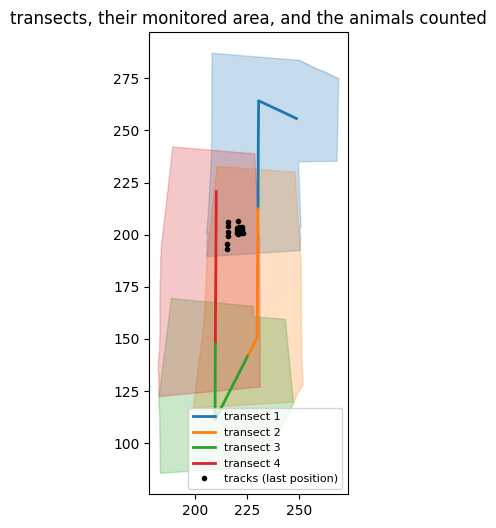

In [9]:
from bambi.survey.transects import split_into, transect_lengths
from bambi.survey.population import (assign_to_transects, merged_footprint_area, points_in_geometries,
                                     geometry_rings, estimate_population)

ranges = split_into(cum[:last + 1], 6)                     # (6, 2) frame ranges over the flight up to the last annotation
ranges = ranges[ranges[:, 1] >= first]                     # keep those touching the annotated stretch
lengths = transect_lengths(cum, ranges)
lines = [centerline(poses.positions, a, b) for a, b in ranges]
areas_m2, geoms = [], []
for a, b in ranges:
    fps = [footprint(cam, W, H, dem.mesh) for cam in cameras_from_poses(poses, FOVY, W / H, t_corr, r_corr,
                                                                       indices=np.arange(a, b + 1, step))]
    area, geom = merged_footprint_area(fps)
    areas_m2.append(area); geoms.append(geom)
areas_ha = np.array(areas_m2) / 1e4

inside = points_in_geometries(track_pts, geoms)
assign = assign_to_transects(track_pts, lines, truncation=0.0, inside=inside)
counts = assign.counts(len(ranges))
print(f"{'transect':>8s} {'frames':>12s} {'length m':>9s} {'area ha':>8s} {'animals':>8s}")
for i, ((a, b), ln, ha, n) in enumerate(zip(ranges, lengths, areas_ha, counts)):
    print(f"{i + 1:8d} {a:5d}-{b:<6d} {ln:9.0f} {ha:8.2f} {n:8d}")
print(f"{int(assign.outside.sum())} track(s) fell outside every footprint and were not counted")

fig, ax = plt.subplots(figsize=(7, 6))
for i, (geom, line) in enumerate(zip(geoms, lines)):
    for ring in geometry_rings(geom):
        ax.add_patch(MplPolygon(ring, closed=True, alpha=0.25, color=f"C{i}"))
    ax.plot(line[:, 0], line[:, 1], "-", color=f"C{i}", lw=2, label=f"transect {i + 1}")
ax.plot(track_pts[:, 0], track_pts[:, 1], "k.", ms=6, label="tracks (last position)")
ax.set_aspect("equal"); ax.legend(fontsize=8); ax.set_title("transects, their monitored area, and the animals counted"); plt.show()

In [10]:
est = estimate_population(counts, areas_ha, methods=("naive", "bootstrap", "zinb"), n_boot=999, seed=42)
print(f"{est.n_transects} transects, {est.total_count:.0f} animals over {est.total_ha:.2f} ha, {est.n_zero_transects} empty")
print(f"naive     {est.naive.density_per_100ha:6.1f} animals per 100 ha")
print(f"bootstrap {est.bootstrap.density_per_100ha:6.1f}  (95% CI {est.bootstrap.ci95[0]:.1f}-{est.bootstrap.ci95[1]:.1f}, SE {est.bootstrap.se:.1f})")
z = est.zinb
if z.density_per_100ha is not None:
    ci = f"(95% CI {z.ci95[0]:.1f}-{z.ci95[1]:.1f})" if z.ci95 else "(no CI)"
    print(f"zinb      {z.density_per_100ha:6.1f}  {ci}  theta {z.theta:.2f}, p_zero {z.zero_inflation_prob:.2f}")
if z.error:
    print("zinb note:", z.error)

4 transects, 16 animals over 1.99 ha, 2 empty
naive      804.6 animals per 100 ha
bootstrap  795.4  (95% CI 0.0-1529.4, SE 371.0)
zinb       801.1  (95% CI 403.9-1198.2)  theta 143566876.13, p_zero 0.50


With six transects and sixteen animals the ZINB is asked for more than the data can identify, and it says so - a parameter that runs to its boundary is flagged instead of quietly reported. On the flights the method was built for (dozens of transects, hundreds of hectares) it reproduces the R analysis; the two published cells from Praschl et al. 2026 are carried along as a check:

In [11]:
from bambi.survey.population import estimate_zinb, estimate_naive
counts_ref = [0] * 26 + [1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 3, 4, 5]
areas_ref = [1.488923, 1.599765, 1.690057, 1.714709, 1.726957, 1.757419, 1.791569, 1.808079, 1.890679, 1.948752, 2.021423,
             2.021726, 2.059094, 2.065921, 2.072363, 2.088126, 2.101806, 2.123316, 2.129358, 2.158377, 2.203595, 2.264995,
             2.276287, 2.448357, 2.708561, 2.731780, 1.834966, 1.949574, 1.996594, 2.132053, 2.241751, 2.628096, 2.875178,
             1.778265, 1.988550, 2.199333, 2.257071, 2.149337, 2.208404, 1.845604]
ref = estimate_zinb(counts_ref, areas_ref)
print(f"ststefan x Daim2: zinb {ref.density_per_100ha:.3f} +- {ref.se:.3f} per 100 ha   (glmmTMB: 32.672 +- 2.495)")
print(f"                  naive {estimate_naive(counts_ref, areas_ref).density_per_100ha:.3f}")

ststefan x Daim2: zinb 32.672 +- 2.495 per 100 ha   (glmmTMB: 32.672 +- 2.495)
                  naive 32.539


## Where this goes next

`05_rendering` closes the loop: the frames themselves projected onto the DEM as orthophotos and light-field integrals - the products the analytics above are usually looked at on top of. Every step of this notebook is asserted against the QGIS plugin's implementation in `tests/test_survey_*.py` (with `BAMBI_PLUGIN_REPO` set), and the population estimators against glmmTMB.